## Imports and project paths

In [1]:
# ============================================================
# 01. Imports and project paths
# ============================================================

from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    recall_score
)

# ------------------------------------------------------------
# Project directories
# ------------------------------------------------------------

BASE_DIR = Path.cwd().parent

DATA_PATH = (
    BASE_DIR
    / "data"
    / "synthetic"
    / "earlysignal_monitoring_data.csv"
)

MODEL_DIR = BASE_DIR / "models"
OUTPUT_DIR = BASE_DIR / "outputs"

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Base directory:")
print(BASE_DIR)

print("\nDataset path:")
print(DATA_PATH)

print("\nDataset exists:")
print(DATA_PATH.exists())

print("\nModel directory:")
print(MODEL_DIR)

print("\nOutput directory:")
print(OUTPUT_DIR)

Base directory:
C:\Users\Ezekiel Mbaya\myenv\EarlySignal_AI

Dataset path:
C:\Users\Ezekiel Mbaya\myenv\EarlySignal_AI\data\synthetic\earlysignal_monitoring_data.csv

Dataset exists:
True

Model directory:
C:\Users\Ezekiel Mbaya\myenv\EarlySignal_AI\models

Output directory:
C:\Users\Ezekiel Mbaya\myenv\EarlySignal_AI\outputs


## Load the V2 dataset

In [2]:
# ============================================================
# 02. Load V2 monitoring dataset
# ============================================================

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["reporting_date"]
)

print("=" * 60)
print("EARLYSIGNAL AI — RISK INTELLIGENCE DATA")
print("=" * 60)

print("\nDataset shape:")
print(df.shape)

print("\nDate range:")
print(
    df["reporting_date"].min(),
    "to",
    df["reporting_date"].max()
)

print("\nRisk distribution:")
print(
    df["risk_label"]
    .value_counts()
)

print("\nRisk distribution (%):")
print(
    df["risk_label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

EARLYSIGNAL AI — RISK INTELLIGENCE DATA

Dataset shape:
(7680, 22)

Date range:
2024-01-01 00:00:00 to 2026-08-01 00:00:00

Risk distribution:
risk_label
Low       4245
Medium    2759
High       676
Name: count, dtype: int64

Risk distribution (%):
risk_label
Low       55.27
Medium    35.92
High       8.80
Name: proportion, dtype: float64


## Validate target quality

In [3]:
# ============================================================
# 03. Validate risk target
# ============================================================

expected_classes = {
    "Low",
    "Medium",
    "High"
}

actual_classes = set(
    df["risk_label"].dropna().unique()
)

print("=" * 60)
print("RISK TARGET VALIDATION")
print("=" * 60)

print(
    "\nMissing risk labels:",
    df["risk_label"].isna().sum()
)

print(
    "Observed classes:",
    sorted(actual_classes)
)

print(
    "Expected classes present:",
    actual_classes == expected_classes
)

print(
    "\nDuplicate rows:",
    df.duplicated().sum()
)

RISK TARGET VALIDATION

Missing risk labels: 0
Observed classes: ['High', 'Low', 'Medium']
Expected classes present: True

Duplicate rows: 0


## Define features and target

In [4]:
# ============================================================
# 04. Define risk-model features and target
# ============================================================

numeric_features = [
    "achievement_rate",
    "activity_completion_rate",
    "budget_utilisation_rate",
    "reporting_delay_days",
    "complaints_count",
    "staff_availability_rate",
    "supply_delay_days",
    "previous_month_achievement_rate",
    "access_constraint_score",
    "data_quality_score"
]

categorical_features = [
    "programme_name",
    "sector",
    "state",
    "lga",
    "community"
]

target = "risk_label"

feature_columns = (
    numeric_features
    + categorical_features
)

print("=" * 60)
print("RISK MODEL FEATURE SET")
print("=" * 60)

print(
    "\nNumeric features:",
    len(numeric_features)
)

print(
    "Categorical features:",
    len(categorical_features)
)

print(
    "Total model features:",
    len(feature_columns)
)

print(
    "\nTarget:",
    target
)

print("\nModel features:")

for feature in feature_columns:
    print(f" - {feature}")

RISK MODEL FEATURE SET

Numeric features: 10
Categorical features: 5
Total model features: 15

Target: risk_label

Model features:
 - achievement_rate
 - activity_completion_rate
 - budget_utilisation_rate
 - reporting_delay_days
 - complaints_count
 - staff_availability_rate
 - supply_delay_days
 - previous_month_achievement_rate
 - access_constraint_score
 - data_quality_score
 - programme_name
 - sector
 - state
 - lga
 - community


## Leakage audit

In [5]:
# ============================================================
# 05. Leakage audit
# ============================================================

forbidden_features = {
    "risk_label",
    "recommended_action",
    "anomaly_flag",
    "monthly_achievement",
    "record_id"
}

selected_features = set(
    feature_columns
)

potential_leakage = (
    selected_features
    & forbidden_features
)

print("=" * 60)
print("RISK MODEL LEAKAGE AUDIT")
print("=" * 60)

print(
    "\nForbidden features:",
    sorted(forbidden_features)
)

print(
    "\nPotential leakage features:",
    potential_leakage
)

if len(potential_leakage) == 0:
    print("\nLeakage audit: PASSED")
else:
    print("\nLeakage audit: FAILED")

RISK MODEL LEAKAGE AUDIT

Forbidden features: ['anomaly_flag', 'monthly_achievement', 'recommended_action', 'record_id', 'risk_label']

Potential leakage features: set()

Leakage audit: PASSED


## Time-based train/test split

In [6]:
# ============================================================
# 06. Time-based train/test split
# ============================================================

model_df = df.sort_values(
    "reporting_date"
).copy()

split_date = pd.Timestamp(
    "2026-02-01"
)

train_df = model_df[
    model_df["reporting_date"] < split_date
].copy()

test_df = model_df[
    model_df["reporting_date"] >= split_date
].copy()

print("=" * 60)
print("TIME-BASED TRAIN / TEST SPLIT")
print("=" * 60)

print(
    "\nSplit date:",
    split_date.date()
)

print("\nTraining data:")
print(
    "Rows:",
    len(train_df)
)

print(
    "Date range:",
    train_df["reporting_date"].min().date(),
    "to",
    train_df["reporting_date"].max().date()
)

print("\nTesting data:")
print(
    "Rows:",
    len(test_df)
)

print(
    "Date range:",
    test_df["reporting_date"].min().date(),
    "to",
    test_df["reporting_date"].max().date()
)

TIME-BASED TRAIN / TEST SPLIT

Split date: 2026-02-01

Training data:
Rows: 6000
Date range: 2024-01-01 to 2026-01-01

Testing data:
Rows: 1680
Date range: 2026-02-01 to 2026-08-01


## Check class balance across train and test

In [7]:
# ============================================================
# 07. Check class balance across train and test
# ============================================================

train_distribution = (
    train_df[target]
    .value_counts()
    .reindex(
        ["Low", "Medium", "High"],
        fill_value=0
    )
)

test_distribution = (
    test_df[target]
    .value_counts()
    .reindex(
        ["Low", "Medium", "High"],
        fill_value=0
    )
)

class_balance = pd.DataFrame({
    "Train Count": train_distribution,
    "Train %": (
        train_distribution
        / len(train_df)
        * 100
    ).round(2),

    "Test Count": test_distribution,
    "Test %": (
        test_distribution
        / len(test_df)
        * 100
    ).round(2)
})

print("=" * 60)
print("RISK CLASS BALANCE — TRAIN VS TEST")
print("=" * 60)

display(class_balance)

RISK CLASS BALANCE — TRAIN VS TEST


,Train Count,Train %,Test Count,Test %
risk_label,,,,
Low,3307,55.12,938,55.83
Medium,2140,35.67,619,36.85
High,553,9.22,123,7.32


## Prepare X and y

In [8]:
# ============================================================
# 08. Prepare training and testing features
# ============================================================

X_train = train_df[
    feature_columns
].copy()

y_train = train_df[
    target
].copy()

X_test = test_df[
    feature_columns
].copy()

y_test = test_df[
    target
].copy()

print("=" * 60)
print("MODEL MATRICES")
print("=" * 60)

print("\nX_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nX_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print(
    "\nMissing values in X_train:",
    X_train.isna().sum().sum()
)

print(
    "Missing values in X_test:",
    X_test.isna().sum().sum()
)

MODEL MATRICES

X_train shape: (6000, 15)
y_train shape: (6000,)

X_test shape: (1680, 15)
y_test shape: (1680,)

Missing values in X_train: 0
Missing values in X_test: 0


## Build preprocessing pipeline

In [9]:
# ============================================================
# 09. Build preprocessing pipeline
# ============================================================

numeric_transformer = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

print(
    "Preprocessing pipeline created successfully."
)

Preprocessing pipeline created successfully.


## Build balanced Logistic Regression

In [10]:
# ============================================================
# 10. Build balanced Logistic Regression risk model
# ============================================================

risk_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                class_weight="balanced",
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

print(
    "Balanced Logistic Regression "
    "risk pipeline created successfully."
)

Balanced Logistic Regression risk pipeline created successfully.


## Train the model

In [11]:
# ============================================================
# 11. Train Risk Intelligence model
# ============================================================

risk_model.fit(
    X_train,
    y_train
)

print("=" * 60)
print("RISK MODEL TRAINING")
print("=" * 60)

print(
    "\nBalanced Logistic Regression "
    "training complete."
)

print(
    "Training observations:",
    len(X_train)
)

RISK MODEL TRAINING

Balanced Logistic Regression training complete.
Training observations: 6000


## Generate predictions and probabilities

In [12]:
# ============================================================
# 12. Generate risk predictions and probabilities
# ============================================================

risk_predictions = risk_model.predict(
    X_test
)

risk_probabilities = risk_model.predict_proba(
    X_test
)

risk_classes = (
    risk_model
    .named_steps["model"]
    .classes_
)

probability_df = pd.DataFrame(
    risk_probabilities,
    columns=[
        f"probability_{risk_class.lower()}"
        for risk_class in risk_classes
    ],
    index=X_test.index
)

print("=" * 60)
print("RISK PREDICTIONS GENERATED")
print("=" * 60)

print(
    "\nPredictions generated:",
    len(risk_predictions)
)

print(
    "Probability rows:",
    len(probability_df)
)

print(
    "\nModel classes:",
    list(risk_classes)
)

print("\nPredicted class distribution:")

print(
    pd.Series(
        risk_predictions
    )
    .value_counts()
    .reindex(
        ["Low", "Medium", "High"],
        fill_value=0
    )
)

RISK PREDICTIONS GENERATED

Predictions generated: 1680
Probability rows: 1680

Model classes: ['High', 'Low', 'Medium']

Predicted class distribution:
Low       925
Medium    615
High      140
Name: count, dtype: int64


## Core classification performance

In [13]:
# ============================================================
# 13. Evaluate core classification performance
# ============================================================

accuracy = accuracy_score(
    y_test,
    risk_predictions
)

macro_f1 = f1_score(
    y_test,
    risk_predictions,
    average="macro"
)

high_risk_recall = recall_score(
    y_test,
    risk_predictions,
    labels=["High"],
    average="macro"
)

print("=" * 60)
print("RISK INTELLIGENCE MODEL PERFORMANCE")
print("=" * 60)

print(
    f"\nAccuracy:         {accuracy:.4f}"
)

print(
    f"Macro F1:         {macro_f1:.4f}"
)

print(
    f"High-Risk Recall: {high_risk_recall:.4f}"
)

RISK INTELLIGENCE MODEL PERFORMANCE

Accuracy:         0.9810
Macro F1:         0.9649
High-Risk Recall: 0.9919


## Full classification report

In [14]:
# ============================================================
# 14. Per-class classification performance
# ============================================================

class_order = [
    "Low",
    "Medium",
    "High"
]

report = classification_report(
    y_test,
    risk_predictions,
    labels=class_order,
    output_dict=True,
    zero_division=0
)

report_df = (
    pd.DataFrame(report)
    .transpose()
)

print("=" * 70)
print("PER-CLASS CLASSIFICATION REPORT")
print("=" * 70)

display(
    report_df[
        [
            "precision",
            "recall",
            "f1-score",
            "support"
        ]
    ].round(4)
)

PER-CLASS CLASSIFICATION REPORT


,precision,recall,f1-score,support
Low,1.0000,0.9861,0.9930,938.000
Medium,0.9772,0.9709,0.9741,619.000
High,0.8714,0.9919,0.9278,123.000
accuracy,0.9810,0.9810,0.9810,0.981
macro avg,0.9496,0.9830,0.9649,1680.000
weighted avg,0.9822,0.9810,0.9813,1680.000


## Confusion matrix table

In [15]:
# ============================================================
# 15. Confusion matrix
# ============================================================

cm = confusion_matrix(
    y_test,
    risk_predictions,
    labels=class_order
)

confusion_df = pd.DataFrame(
    cm,
    index=[
        f"Actual {label}"
        for label in class_order
    ],
    columns=[
        f"Predicted {label}"
        for label in class_order
    ]
)

print("=" * 70)
print("RISK CLASSIFICATION CONFUSION MATRIX")
print("=" * 70)

display(confusion_df)

RISK CLASSIFICATION CONFUSION MATRIX


,Predicted Low,Predicted Medium,Predicted High
Actual Low,925,13,0
Actual Medium,0,601,18
Actual High,0,1,122


## Confusion matrix visualization

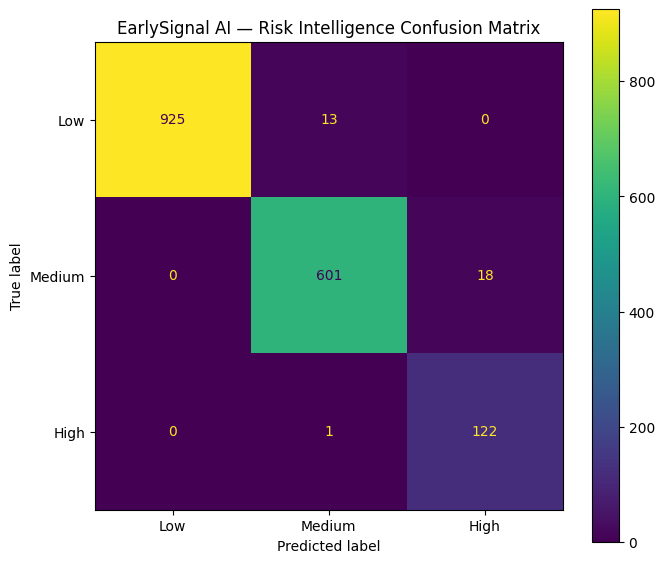

In [16]:
# ============================================================
# 16. Visualize confusion matrix
# ============================================================

fig, ax = plt.subplots(
    figsize=(7, 6)
)

display_cm = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_order
)

display_cm.plot(
    ax=ax,
    values_format="d"
)

ax.set_title(
    "EarlySignal AI — Risk Intelligence Confusion Matrix"
)

plt.tight_layout()
plt.show()

## High-Risk detection audit

In [17]:
# ============================================================
# 17. High-Risk detection audit
# ============================================================

actual_high = (
    y_test.values == "High"
)

predicted_high = (
    risk_predictions == "High"
)

high_detected = (
    actual_high
    & predicted_high
).sum()

high_missed = (
    actual_high
    & ~predicted_high
).sum()

high_false_alarms = (
    ~actual_high
    & predicted_high
).sum()

total_actual_high = (
    actual_high.sum()
)

total_predicted_high = (
    predicted_high.sum()
)

print("=" * 60)
print("HIGH-RISK DETECTION AUDIT")
print("=" * 60)

print(
    f"\nActual High-Risk cases:    "
    f"{total_actual_high:,}"
)

print(
    f"Predicted High-Risk cases: "
    f"{total_predicted_high:,}"
)

print(
    f"High-Risk cases detected:  "
    f"{high_detected:,}"
)

print(
    f"High-Risk cases missed:    "
    f"{high_missed:,}"
)

print(
    f"High-Risk false alarms:    "
    f"{high_false_alarms:,}"
)

print(
    f"\nHigh-Risk Recall: "
    f"{high_risk_recall:.2%}"
)

print(
    "\nDecision-use note: High-Risk predictions are "
    "early-warning signals recommended for human review."
)

HIGH-RISK DETECTION AUDIT

Actual High-Risk cases:    123
Predicted High-Risk cases: 140
High-Risk cases detected:  122
High-Risk cases missed:    1
High-Risk false alarms:    18

High-Risk Recall: 99.19%

Decision-use note: High-Risk predictions are early-warning signals recommended for human review.


## Risk prediction distribution

In [18]:
# ============================================================
# 18. Risk prediction distribution
# ============================================================

actual_distribution = (
    pd.Series(y_test.values)
    .value_counts()
    .reindex(
        ["Low", "Medium", "High"],
        fill_value=0
    )
)

predicted_distribution = (
    pd.Series(risk_predictions)
    .value_counts()
    .reindex(
        ["Low", "Medium", "High"],
        fill_value=0
    )
)

risk_distribution_comparison = pd.DataFrame({
    "Actual Count": actual_distribution,
    "Actual %": (
        actual_distribution
        / len(y_test)
        * 100
    ).round(2),

    "Predicted Count": predicted_distribution,
    "Predicted %": (
        predicted_distribution
        / len(risk_predictions)
        * 100
    ).round(2)
})

print("=" * 70)
print("ACTUAL VS PREDICTED RISK DISTRIBUTION")
print("=" * 70)

display(risk_distribution_comparison)

ACTUAL VS PREDICTED RISK DISTRIBUTION


,Actual Count,Actual %,Predicted Count,Predicted %
Low,938,55.83,925,55.06
Medium,619,36.85,615,36.61
High,123,7.32,140,8.33


## Extract Logistic Regression coefficients

In [19]:
# ============================================================
# 19. Extract Risk Intelligence model coefficients
# ============================================================

fitted_preprocessor = (
    risk_model.named_steps["preprocessor"]
)

fitted_classifier = (
    risk_model.named_steps["model"]
)

feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)

coefficient_df = pd.DataFrame(
    fitted_classifier.coef_,
    index=fitted_classifier.classes_,
    columns=feature_names
).T

print("=" * 70)
print("RISK MODEL COEFFICIENTS")
print("=" * 70)

print(
    "\nTransformed features:",
    len(feature_names)
)

print(
    "Model classes:",
    list(fitted_classifier.classes_)
)

display(
    coefficient_df.head(10).round(4)
)

RISK MODEL COEFFICIENTS

Transformed features: 77
Model classes: ['High', 'Low', 'Medium']


,High,Low,Medium
numeric__achievement_rate,-8.1479,9.0916,-0.9437
numeric__activity_completion_rate,-3.6531,4.1686,-0.5155
numeric__budget_utilisation_rate,0.0346,-0.0058,-0.0288
numeric__reporting_delay_days,4.5305,-5.3147,0.7842
numeric__complaints_count,2.2597,-2.5821,0.3224
numeric__staff_availability_rate,-0.7858,0.9100,-0.1242
numeric__supply_delay_days,3.9371,-4.4554,0.5183
numeric__previous_month_achievement_rate,0.1336,-0.0193,-0.1143
numeric__access_constraint_score,1.5452,-1.8426,0.2974
numeric__data_quality_score,-0.3497,0.4887,-0.1391


## Top High-Risk drivers

In [20]:
# ============================================================
# 20. Top High-Risk model drivers
# ============================================================

high_risk_drivers = (
    coefficient_df[
        ["High"]
    ]
    .rename(
        columns={
            "High": "coefficient"
        }
    )
    .sort_values(
        "coefficient",
        ascending=False
    )
)

print("=" * 70)
print("TOP HIGH-RISK DRIVERS")
print("=" * 70)

print(
    "\nFeatures with larger positive coefficients "
    "increase the model's tendency toward the High-Risk class."
)

display(
    high_risk_drivers.head(15).round(4)
)

TOP HIGH-RISK DRIVERS

Features with larger positive coefficients increase the model's tendency toward the High-Risk class.


,coefficient
numeric__reporting_delay_days,4.5305
numeric__supply_delay_days,3.9371
numeric__complaints_count,2.2597
numeric__access_constraint_score,1.5452
categorical__community_Gwoza Site 2,0.8137
categorical__community_Dikwa Site 2,0.6907
categorical__community_Maiduguri Site 1,0.6600
categorical__community_Mafa Site 6,0.5878
categorical__community_Bama Site 4,0.5374
categorical__community_Ngala Site 1,0.5029


In [21]:
# ============================================================
# 21. Strongest Low-Risk / Protective Signals
# ============================================================

print("=" * 70)
print("STRONGEST SIGNALS AWAY FROM HIGH RISK")
print("=" * 70)

print(
    "\nFeatures with more negative High-Risk coefficients "
    "reduce the model's tendency toward the High-Risk class."
)

display(
    high_risk_drivers.tail(15)
    .sort_values("coefficient")
    .round(4)
)

STRONGEST SIGNALS AWAY FROM HIGH RISK

Features with more negative High-Risk coefficients reduce the model's tendency toward the High-Risk class.


,coefficient
numeric__achievement_rate,-8.1479
numeric__activity_completion_rate,-3.6531
categorical__community_Dikwa Site 4,-0.9241
numeric__staff_availability_rate,-0.7858
categorical__community_Maiduguri Site 5,-0.6466
categorical__community_Jere Site 3,-0.6329
categorical__community_Konduga Site 2,-0.5469
categorical__community_Maiduguri Site 6,-0.4328
categorical__community_Maiduguri Site 2,-0.4095
categorical__community_Ngala Site 6,-0.3802


## Build standardized risk results

In [22]:
# ============================================================
# 22. Build standardized Risk Intelligence results
# ============================================================

risk_results = test_df[
    [
        "record_id",
        "reporting_date",
        "programme_name",
        "sector",
        "state",
        "lga",
        "community",
        "achievement_rate",
        "risk_label"
    ]
].copy()

risk_results[
    "predicted_risk"
] = risk_predictions

# Add class probabilities using the model's actual class order
for risk_class in risk_classes:
    risk_results[
        f"probability_{risk_class.lower()}"
    ] = probability_df[
        f"probability_{risk_class.lower()}"
    ].values

risk_results[
    "risk_prediction_correct"
] = (
    risk_results["risk_label"]
    == risk_results["predicted_risk"]
)

print("=" * 70)
print("STANDARDIZED RISK INTELLIGENCE RESULTS")
print("=" * 70)

print(
    "\nRows:",
    len(risk_results)
)

print(
    "Columns:",
    len(risk_results.columns)
)

print("\nOutput columns:")

for column in risk_results.columns:
    print(f" - {column}")

print("\nPreview:")

display(
    risk_results.head()
)

STANDARDIZED RISK INTELLIGENCE RESULTS

Rows: 1680
Columns: 14

Output columns:
 - record_id
 - reporting_date
 - programme_name
 - sector
 - state
 - lga
 - community
 - achievement_rate
 - risk_label
 - predicted_risk
 - probability_high
 - probability_low
 - probability_medium
 - risk_prediction_correct

Preview:


,record_id,reporting_date,programme_name,sector,state,lga,community,achievement_rate,risk_label,predicted_risk,probability_high,probability_low,probability_medium,risk_prediction_correct
5209,ES-004826,2026-02-01,Nutrition Support Programme,Nutrition,Borno,Jere,Jere Site 1,0.6975,Medium,Medium,1.176303e-03,1.207381e-04,9.987030e-01,True
4057,ES-002138,2026-02-01,Livelihood Recovery Initiative,Livelihoods,Borno,Mafa,Mafa Site 1,0.5252,High,High,9.815632e-01,1.292590e-13,1.843680e-02,True
4665,ES-005434,2026-02-01,Nutrition Support Programme,Nutrition,Borno,Bama,Bama Site 2,0.8341,Low,Low,1.100324e-21,1.000000e+00,6.434049e-10,True
1049,ES-000666,2026-02-01,Community Resilience Programme,Protection/Resilience,Borno,Mafa,Mafa Site 3,0.8349,Low,Low,3.673446e-17,9.999996e-01,4.033462e-07,True
1209,ES-000058,2026-02-01,Community Resilience Programme,Protection/Resilience,Borno,Maiduguri,Maiduguri Site 2,0.8009,Low,Low,2.345190e-15,9.999931e-01,6.901590e-06,True


## Show highest-priority risk cases

In [23]:
# ============================================================
# 23. Show highest-priority risk cases
# ============================================================

highest_risk_cases = (
    risk_results[
        [
            "reporting_date",
            "programme_name",
            "sector",
            "state",
            "lga",
            "community",
            "achievement_rate",
            "predicted_risk",
            "probability_high"
        ]
    ]
    .sort_values(
        "probability_high",
        ascending=False
    )
    .head(20)
)

print("=" * 70)
print("HIGHEST-PRIORITY RISK CASES")
print("=" * 70)

display(highest_risk_cases)

HIGHEST-PRIORITY RISK CASES


,reporting_date,programme_name,sector,state,lga,community,achievement_rate,predicted_risk,probability_high
5083,2026-04-01,Nutrition Support Programme,Nutrition,Borno,Gwoza,Gwoza Site 3,0.6906,High,1.0
3455,2026-08-01,Livelihood Recovery Initiative,Livelihoods,Borno,Dikwa,Dikwa Site 6,0.5137,High,1.0
3193,2026-02-01,Livelihood Recovery Initiative,Livelihoods,Borno,Bama,Bama Site 4,0.6450,High,1.0
7614,2026-07-01,WASH Resilience Initiative,WASH,Borno,Ngala,Ngala Site 4,0.7309,High,1.0
7099,2026-04-01,WASH Resilience Initiative,WASH,Borno,Konduga,Konduga Site 6,0.2673,High,1.0
3130,2026-03-01,Livelihood Recovery Initiative,Livelihoods,Borno,Bama,Bama Site 2,0.7053,High,1.0
3227,2026-04-01,Livelihood Recovery Initiative,Livelihoods,Borno,Bama,Bama Site 5,0.6851,High,1.0
3098,2026-03-01,Livelihood Recovery Initiative,Livelihoods,Borno,Bama,Bama Site 1,0.6946,High,1.0
1823,2026-08-01,Education Access Project,Education,Borno,Dikwa,Dikwa Site 3,0.2886,High,1.0
6877,2026-06-01,WASH Resilience Initiative,WASH,Borno,Jere,Jere Site 5,0.3135,High,1.0


## Save model and outputs

In [24]:
# ============================================================
# 24. Save model and outputs
# ============================================================

MODEL_PATH = (
    MODEL_DIR
    / "earlysignal_risk_model.joblib"
)

RESULTS_PATH = (
    OUTPUT_DIR
    / "risk_results.csv"
)

joblib.dump(
    risk_model,
    MODEL_PATH
)

risk_results.to_csv(
    RESULTS_PATH,
    index=False
)

print("=" * 65)
print("EARLYSIGNAL AI — RISK MODEL AND OUTPUTS SAVED")
print("=" * 65)

print("\nModel saved to:")
print(MODEL_PATH)

print(
    "Model file exists:",
    MODEL_PATH.exists()
)

print("\nRisk results saved to:")
print(RESULTS_PATH)

print(
    "Risk results file exists:",
    RESULTS_PATH.exists()
)

print(
    "\nRisk rows saved:",
    len(risk_results)
)

print(
    "Risk columns saved:",
    len(risk_results.columns)
)

EARLYSIGNAL AI — RISK MODEL AND OUTPUTS SAVED

Model saved to:
C:\Users\Ezekiel Mbaya\myenv\EarlySignal_AI\models\earlysignal_risk_model.joblib
Model file exists: True

Risk results saved to:
C:\Users\Ezekiel Mbaya\myenv\EarlySignal_AI\outputs\risk_results.csv
Risk results file exists: True

Risk rows saved: 1680
Risk columns saved: 14


## Final Notebook 04 summary

In [25]:
# ============================================================
# 25. Final Risk Intelligence summary
# ============================================================

high_precision = report_df.loc[
    "High",
    "precision"
]

high_f1 = report_df.loc[
    "High",
    "f1-score"
]

print("=" * 70)
print("EARLYSIGNAL AI — RISK INTELLIGENCE SUMMARY")
print("=" * 70)

print(
    f"Training observations: {len(X_train):,}"
)

print(
    f"Testing observations: {len(X_test):,}"
)

print("\nBalanced Logistic Regression performance:")

print(
    f"Accuracy:         {accuracy:.4f}"
)

print(
    f"Macro F1:         {macro_f1:.4f}"
)

print(
    f"High-Risk Recall: {high_risk_recall:.4f}"
)

print(
    f"High-Risk Precision: {high_precision:.4f}"
)

print(
    f"High-Risk F1:        {high_f1:.4f}"
)

print("\nHigh-Risk detection:")

print(
    f"Actual High-Risk cases:   {total_actual_high:,}"
)

print(
    f"High-Risk cases detected: {high_detected:,}"
)

print(
    f"High-Risk cases missed:   {high_missed:,}"
)

print(
    f"High-Risk false alarms:   {high_false_alarms:,}"
)

print(
    "\nTop High-Risk driver:",
    high_risk_drivers.index[0]
)

print(
    "Top driver coefficient:",
    f"{high_risk_drivers.iloc[0]['coefficient']:.4f}"
)

print("\nLeakage audit: PASSED")

print(
    "Validation note: Performance reflects prototype "
    "validation on synthetic monitoring data."
)

print(
    "Decision-use note: Risk predictions are "
    "decision-support signals recommended for human review."
)

print("\nNotebook 04 complete.")

EARLYSIGNAL AI — RISK INTELLIGENCE SUMMARY
Training observations: 6,000
Testing observations: 1,680

Balanced Logistic Regression performance:
Accuracy:         0.9810
Macro F1:         0.9649
High-Risk Recall: 0.9919
High-Risk Precision: 0.8714
High-Risk F1:        0.9278

High-Risk detection:
Actual High-Risk cases:   123
High-Risk cases detected: 122
High-Risk cases missed:   1
High-Risk false alarms:   18

Top High-Risk driver: numeric__reporting_delay_days
Top driver coefficient: 4.5305

Leakage audit: PASSED
Validation note: Performance reflects prototype validation on synthetic monitoring data.
Decision-use note: Risk predictions are decision-support signals recommended for human review.

Notebook 04 complete.
